# 03 — Backtest

Leakage-free walk-forward evaluation against recent World Cups, baseline comparison, time-decay tuning, and calibration.

*Note: log-loss/RPS here are scored on the W/D/L result probabilities (from `predict_result`), a standard and practical metric. Each model fit takes ~1 min, so this notebook runs for several minutes.*

In [1]:
import sys; sys.path.append("..")
import numpy as np, pandas as pd
from src.dixon_coles import DixonColesModel
from src.evaluate import (walk_forward_worldcups, evaluate, base_rate_probs,
                          result_outcome, calibration_curve)

df = pd.read_parquet("../data/processed/matches.parquet")
wc_years = [2018, 2022]
preds, outs = walk_forward_worldcups(df, wc_years, DixonColesModel, xi=0.0019)
print("matches predicted:", len(outs))
print("model:", {k: round(v, 4) for k, v in evaluate(preds, outs).items()})

matches predicted: 128
model: {'rps': 0.2165, 'log_loss': 1.0155, 'accuracy': 0.5391}


In [2]:
train_outcomes = [result_outcome(r.home_score, r.away_score)
                  for r in df[df.date < "2018-01-01"].itertuples()]
base = base_rate_probs(train_outcomes)
print("base-rate baseline:", {k: round(v, 4) for k, v in evaluate([base] * len(outs), outs).items()})
print("(model RPS and log-loss should be lower = better)")

base-rate baseline: {'rps': 0.2443, 'log_loss': 1.0843, 'accuracy': 0.4141}
(model RPS and log-loss should be lower = better)


In [3]:
results = {}
for xi in [0.0, 0.0019, 0.005]:
    p, o = walk_forward_worldcups(df, wc_years, DixonColesModel, xi=xi)
    results[xi] = evaluate(p, o)["rps"]
best_xi = min(results, key=results.get)
print("RPS by xi:", {k: round(v, 4) for k, v in results.items()})
print("best xi:", best_xi)

RPS by xi: {0.0: 0.2186, 0.0019: 0.2165, 0.005: 0.2167}
best xi: 0.0019


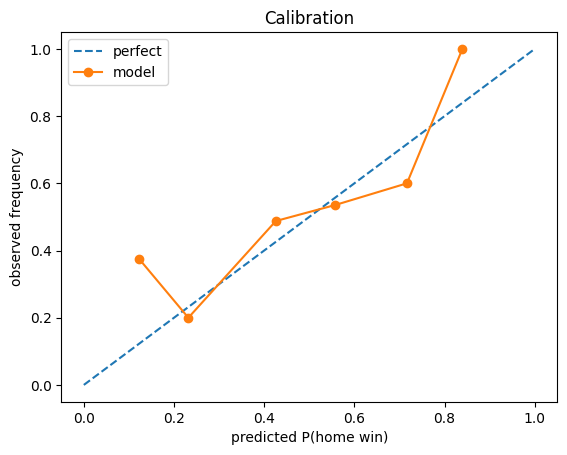

In [4]:
import matplotlib.pyplot as plt
home_probs = [p[0] for p in preds]
home_won = [int(o == 0) for o in outs]
centers, freqs = calibration_curve(home_probs, home_won, n_bins=6)
plt.plot([0, 1], [0, 1], "--", label="perfect")
plt.plot(centers, freqs, "o-", label="model")
plt.xlabel("predicted P(home win)"); plt.ylabel("observed frequency")
plt.legend(); plt.title("Calibration"); plt.show()